In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

In [2]:
def flatten_columns(df):
    df.columns = [
        "_".join(col).upper() if isinstance(col, tuple) else col
        for col in df.columns
    ]
    return df

## 1. Загрузка датасета

Загрузка синтетически расширенного датасета `uplift-dataset.csv`, сформированного в ноутбуке `prepare_dataset.ipynb`. Датасет содержит исходные признаки клиентов Home Credit, дополненные синтетическими uplift-переменными.


In [3]:
DATA_PATH = 'data/processed'  # обработанные данные

In [4]:
np.random.seed(91)

In [5]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 161)


## 2. Верификация синтетически сгенерированных переменных

Проверка корректности синтетически сгенерированных переменных. Для каждой из ключевых переменных оценивается соответствие её статистических свойств правилам, заложенным при генерации: распределение, зависимости, наличие selection bias и гетерогенности эффектов.


In [6]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SK_DPD_MAX_CC,BASE_PD,CONTACT_PROPENSITY,RISK_SEGMENT,CONTACT_HISTORY,PREFERRED_CHANNEL,INTERACTION_SCORE,DELAY_FLAG,COMMUNICATION,TRUE_UPLIFT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,0.950968,0.609805,high_risk,9,sms,0.450668,1,operator_call,0.028513
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,0.608977,0.456933,high_risk,0,operator_call,0.341462,1,control,-0.005344
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,0.227401,0.148340,low_risk,0,sms,0.483622,0,control,0.003340
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.359173,0.253956,low_risk,2,robot_call,0.461974,0,control,-0.021130
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,0.629868,0.420203,high_risk,2,robot_call,0.437186,0,control,-0.004420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,0.661227,0.430674,high_risk,3,operator_call,0.469229,1,control,-0.001041
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,0.671782,0.425683,high_risk,2,sms,0.467030,0,operator_call,-0.068337
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,NaN,0.423995,0.311099,medium_risk,0,sms,0.416992,0,control,-0.010546
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,0.376648,0.259927,low_risk,1,sms,0.455039,1,control,-0.012077


### 2.1 Анализ BASE_PD — базовой вероятности дефолта

**Ожидаемые свойства:**
- Значения в диапазоне [0, 1]
- Правосторонняя асимметрия (большинство клиентов — низкий риск)
- Монотонная положительная корреляция с фактическим TARGET
- Разделение распределений по классам TARGET = 0 и TARGET = 1


**Средние значения BASE_PD по классам TARGET:**


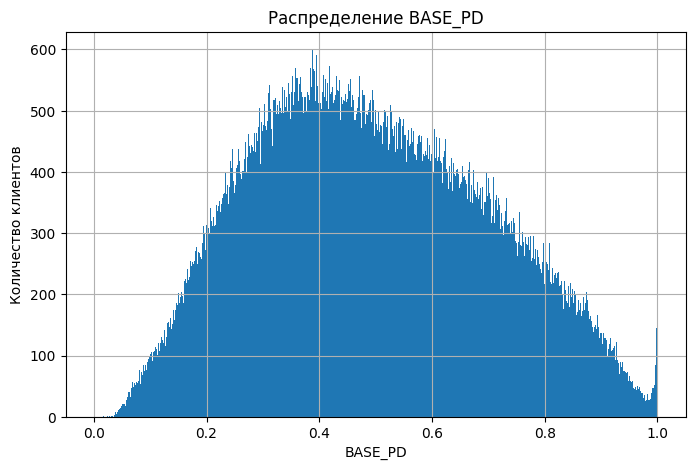

In [15]:
plt.figure(figsize=(8, 5))
df['BASE_PD'].hist(bins=1000)
plt.title("Распределение BASE_PD")
plt.xlabel("BASE_PD")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 1. Распределение BASE_PD.**

Базовая вероятность дефолта имеет правостороннюю асимметрию: большинство клиентов сосредоточено в диапазоне низкого риска (0.0–0.4). Хвост распределения (BASE_PD > 0.7) соответствует высокорисковым заёмщикам.


C:\Users\sharn\AppData\Local\Temp\ipykernel_17124\728099310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()


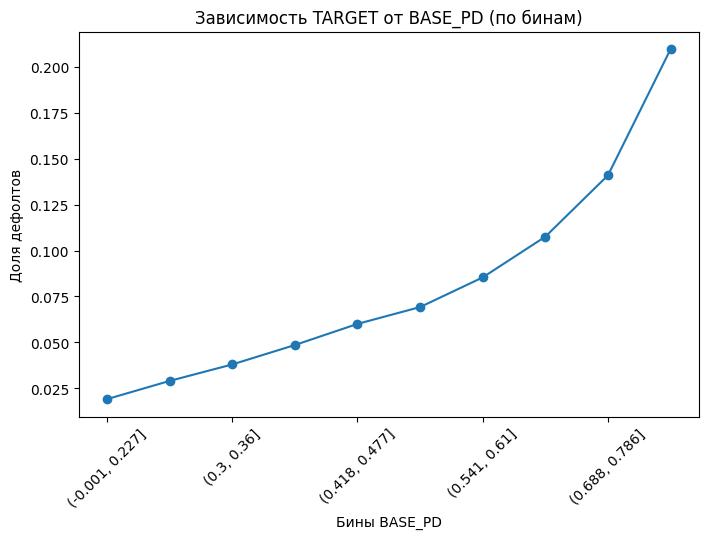

In [8]:
df["BASE_PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()

pd_by_bin.plot(marker="o", figsize=(8, 5))
plt.title("Зависимость TARGET от BASE_PD (по бинам)")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Доля дефолтов")
plt.xticks(rotation=45)
plt.show()

**Рисунок 2. Зависимость TARGET от BASE_PD (по децильным бинам).**

Наблюдается монотонная положительная зависимость: с ростом BASE_PD доля фактических дефолтов (TARGET = 1) закономерно увеличивается. Это подтверждает предсказательную силу BASE_PD как прокси риска дефолта.


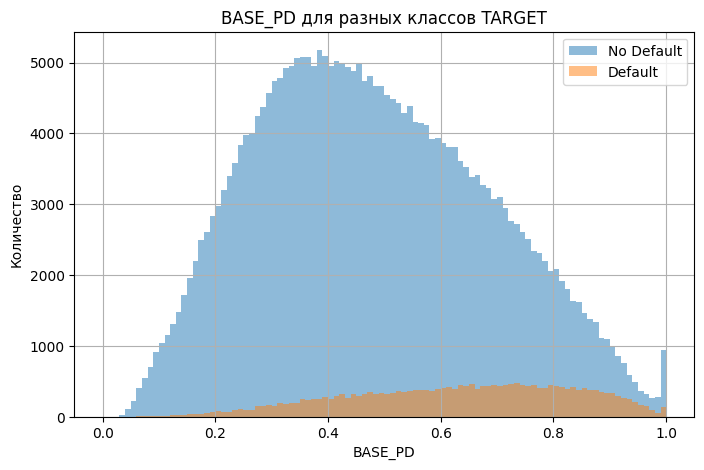

In [9]:
plt.figure(figsize=(8, 5))

df[df["TARGET"] == 0]["BASE_PD"].hist(alpha=0.5, bins=100, label="No Default")
df[df["TARGET"] == 1]["BASE_PD"].hist(alpha=0.5, bins=100, label="Default")

plt.legend()
plt.title("BASE_PD для разных классов TARGET")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

In [10]:
print(f"Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: {df[df["TARGET"] == 0]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: 0.48


In [11]:
print(f"Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: {df[df["TARGET"] == 1]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: 0.63


**Рисунок 3. Распределение BASE_PD по классам TARGET.**

Клиенты с дефолтом (TARGET = 1) имеют заметно более высокие значения BASE_PD по сравнению с платёжеспособными клиентами (TARGET = 0). Разделение распределений подтверждает дискриминирующую силу BASE_PD.


In [17]:
print(f"Значение метрики ROC-AUC равно: {round(roc_auc_score(df["TARGET"], df["BASE_PD"]),3)}, что говорит о наличии умеренной предсказательной способности сгенерированной переменной")

Значение метрики ROC-AUC равно: 0.703, что говорит о наличии умеренной предсказательной способности сгенерированной переменной


### 2.2 Анализ CONTACT_PROPENSITY — пропенсити к контакту

**Ожидаемые свойства:**
- Монотонная положительная зависимость от BASE_PD
- Правосторонняя асимметрия (банк чаще контактирует с высокорисковыми клиентами)
- Значения в диапазоне [0, 1]


**Средние значения CONTACT_PROPENSITY по каналам коммуникации:**


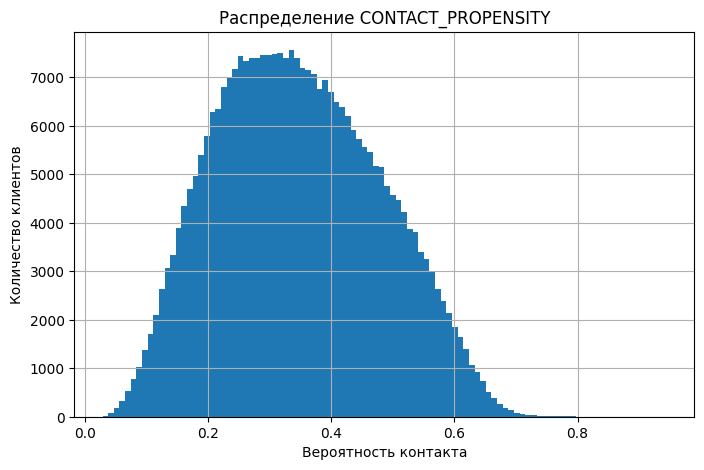

In [33]:
plt.figure(figsize=(8, 5))
df["CONTACT_PROPENSITY"].hist(bins=100)
plt.title("Распределение CONTACT_PROPENSITY")
plt.xlabel("Вероятность контакта")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 4. Распределение CONTACT_PROPENSITY.**

Пропенсити к контакту сконцентрирована в диапазоне 0.3–0.7. Правый хвост отражает долю высокорисковых клиентов, с которыми банк наиболее вероятно инициирует коммуникацию.


C:\Users\sharn\AppData\Local\Temp\ipykernel_17124\1036460096.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()


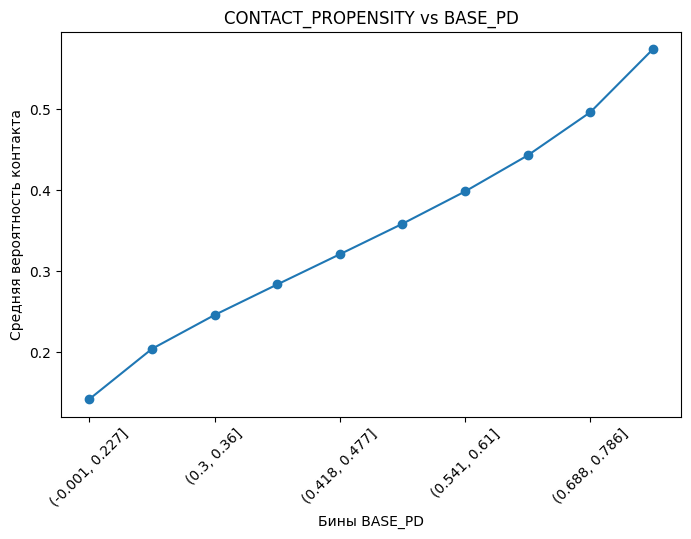

In [19]:
df["PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()

propensity_by_pd.plot(marker="o", figsize=(8, 5))
plt.title("CONTACT_PROPENSITY vs BASE_PD")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Средняя вероятность контакта")
plt.xticks(rotation=45)
plt.show()

**Рисунок 5. Зависимость CONTACT_PROPENSITY от BASE_PD.**

Чёткая монотонная зависимость: чем выше базовый риск клиента, тем с большей вероятностью банк инициирует коммуникацию. Это создаёт **selection bias** — клиенты в группе воздействия систематически отличаются от контрольной группы по уровню риска.


### 2.3 Анализ COMMUNICATION — типа воздействия (selection bias)

**Ожидаемые свойства:**
- Non-random treatment assignment: каналы назначаются в зависимости от уровня риска
- Treated-группа имеет более высокий средний BASE_PD, чем контрольная
- Оператор контактирует с наиболее рисковыми клиентами, SMS — с наименее рисковыми


In [20]:
df["TREATED"] = df["COMMUNICATION"].apply(lambda x: "TREATED" if x != 'control' else "CONTROL")

df.groupby("TREATED")[["BASE_PD", "TARGET","AMT_CREDIT", "AMT_INCOME_TOTAL"]].mean().round(2)

,BASE_PD,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL
TREATED,,,,
CONTROL,0.45,0.07,571684.60,167399.98
TREATED,0.57,0.10,650554.62,171432.54


**Распределение клиентов по каналам коммуникации и средний BASE_PD:**


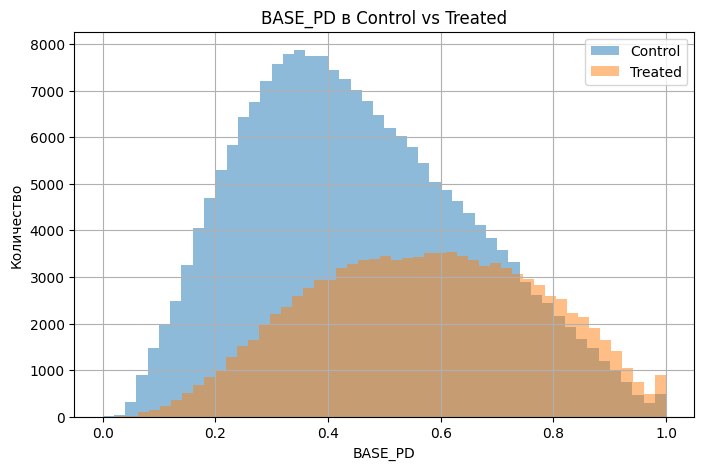

In [21]:
plt.figure(figsize=(8, 5))

df[df["TREATED"] == "CONTROL"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Control")
df[df["TREATED"] == "TREATED"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Treated")

plt.legend()
plt.title("BASE_PD в Control vs Treated")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

**Рисунок 6. BASE_PD в контрольной и тестовой группах.**

Распределения BASE_PD для treated- и control-групп существенно расходятся: клиенты с коммуникацией имеют более высокий средний риск. Это подтверждает **selection bias** в данных, аналогичного реальным наблюдательным исследованиям.


In [22]:
df["COMMUNICATION"].value_counts(normalize=True).round(4) * 100

COMMUNICATION
control          65.33
operator_call    16.54
robot_call       11.34
sms               6.79
Name: proportion, dtype: float64

**Рисунок 7. Распределение BASE_PD по каналам коммуникации (boxplot).**

Иерархия риска по каналам: клиенты с `operator_call` имеют наибольший медианный BASE_PD (~0.75), а SMS-клиенты — наименьший (~0.28). Это подтверждает non-random treatment assignment: высокорисковые клиенты целенаправленно получают более затратные виды воздействия.


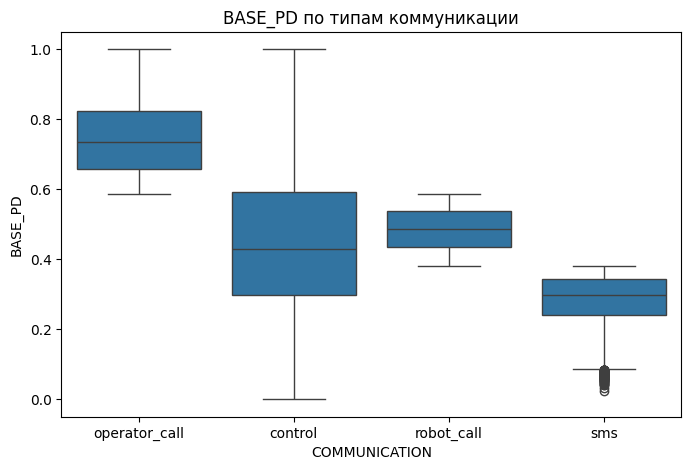

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="COMMUNICATION", y="BASE_PD")
plt.title("BASE_PD по типам коммуникации")
plt.show()

**Кросс-табуляция RISK_SEGMENT vs COMMUNICATION:**

Таблица наглядно демонстрирует, что назначение канала зависит от сегмента риска: клиенты high_risk преимущественно получают звонки оператора, low_risk — SMS или не получают коммуникации вовсе.


In [24]:
df.groupby("COMMUNICATION")["BASE_PD"].mean().round(2).sort_values()

COMMUNICATION
sms              0.28
control          0.45
robot_call       0.49
operator_call    0.75
Name: BASE_PD, dtype: float64

### 2.4 Анализ TRUE_UPLIFT — истинного каузального эффекта

**Ожидаемые свойства:**
- Значения сосредоточены вблизи нуля с небольшим сдвигом в отрицательную сторону
- Гетерогенность: эффект различается по сегментам риска и каналам коммуникации
- Fatigue effect: эффект снижается с ростом CONTACT_HISTORY
- Interaction effect: более сильный отрицательный uplift у клиентов с высоким INTERACTION_SCORE


In [25]:
df.groupby("COMMUNICATION")["CONTACT_PROPENSITY"].mean().round(2)

COMMUNICATION
control          0.32
operator_call    0.50
robot_call       0.35
sms              0.22
Name: CONTACT_PROPENSITY, dtype: float64

**Средние значения BASE_PD и CONTACT_PROPENSITY по каналам коммуникации:**


In [26]:
pd.crosstab(df["RISK_SEGMENT"], df["COMMUNICATION"], normalize="index").round(2)

COMMUNICATION,control,operator_call,robot_call,sms
RISK_SEGMENT,,,,
high_risk,0.50,0.5,0.00,0.0
low_risk,0.80,0.0,0.00,0.2
medium_risk,0.66,0.0,0.34,0.0


**Средний TRUE_UPLIFT по сегментам риска и каналам коммуникации:**


**Рисунок 8. Распределение TRUE_UPLIFT.**

Распределение сосредоточено вблизи нуля и слегка сдвинуто в отрицательную сторону: большинство коммуникаций незначительно снижают вероятность дефолта (отрицательный uplift = улучшение). Наличие положительного хвоста указывает на сегмент клиентов, для которых коммуникация контрпродуктивна.


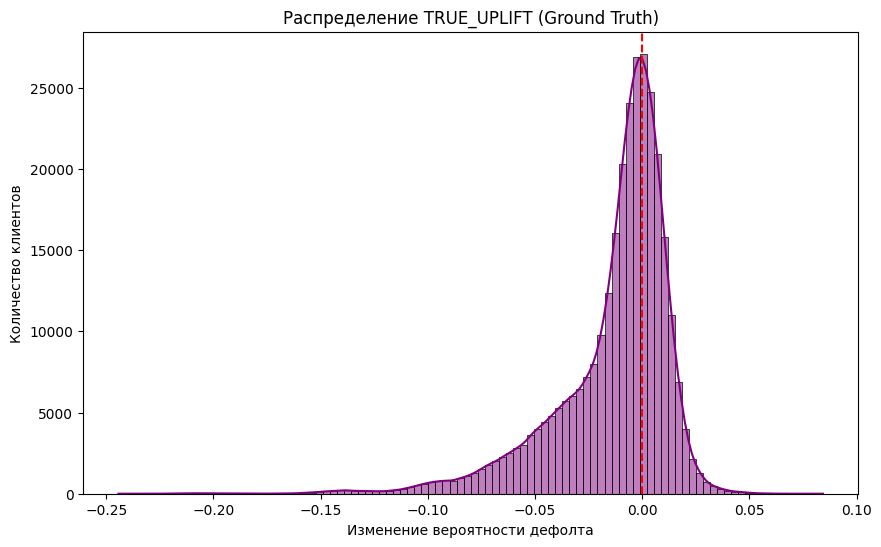

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TRUE_UPLIFT'], bins=100, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Распределение TRUE_UPLIFT (Ground Truth)")
plt.xlabel("Изменение вероятности дефолта")
plt.ylabel("Количество клиентов")
plt.show()

**Рисунок 9. Средний TRUE_UPLIFT по сегментам риска и каналам коммуникации (heatmap).**

Тепловая карта демонстрирует **гетерогенность treatment effect**: эффект коммуникации существенно различается в зависимости от сегмента риска и типа воздействия. Наибольший положительный эффект (снижение PD) наблюдается у высокорисковых клиентов при звонке оператора. SMS наиболее эффективен для низкорисковых клиентов. Именно эта гетерогенность является обоснованием применения uplift-моделирования.


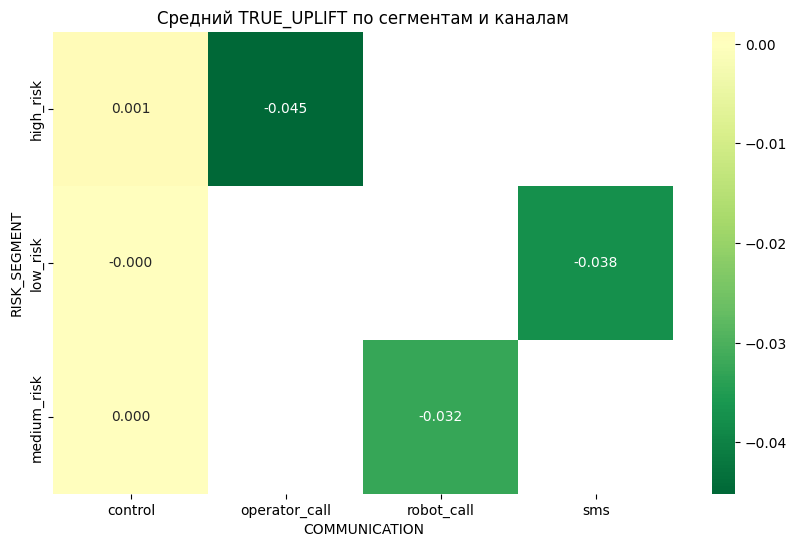

In [28]:
# Матрица эффективности: Сегмент риска vs Канал коммуникации
uplift_pivot = df.groupby(['RISK_SEGMENT', 'COMMUNICATION'])['TRUE_UPLIFT'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(uplift_pivot, annot=True, cmap="RdYlGn_r", center=0, fmt=".3f")
plt.title("Средний TRUE_UPLIFT по сегментам и каналам")
plt.show()

**Рисунок 10. Зависимость TRUE_UPLIFT от истории контактов (Fatigue Effect).**

По мере увеличения числа предыдущих контактов (`CONTACT_HISTORY`) средний эффект коммуникации снижается — иллюстрируется **communication fatigue**. При большом числе предыдущих контактов эффект может становиться положительным (контрпродуктивным). Закономерность воспроизводится для всех каналов коммуникации.


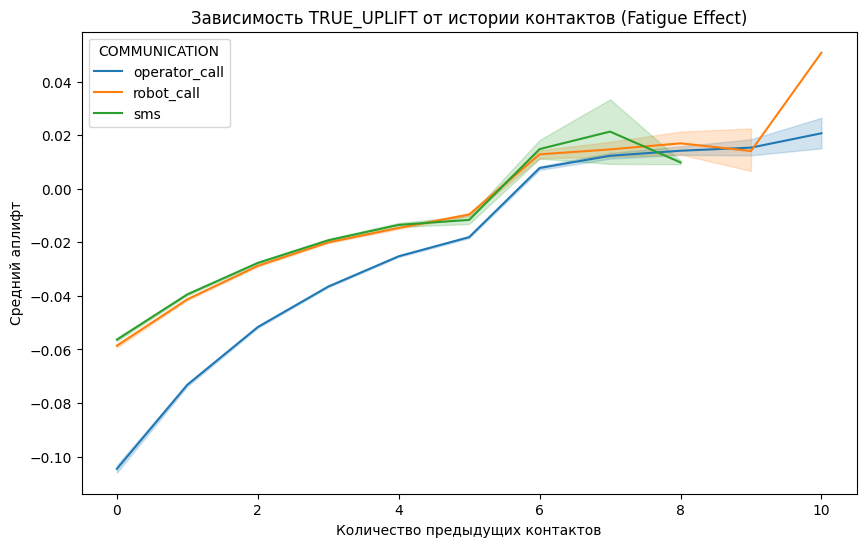

In [29]:
# Визуализация затухания эффекта от количества контактов
plt.figure(figsize=(10, 6))
sns.lineplot(data=df[df['COMMUNICATION'] != 'control'], x='CONTACT_HISTORY', y='TRUE_UPLIFT', hue='COMMUNICATION')
plt.title("Зависимость TRUE_UPLIFT от истории контактов (Fatigue Effect)")
plt.xlabel("Количество предыдущих контактов")
plt.ylabel("Средний аплифт")
plt.show()

**Рисунок 11. Взаимосвязь INTERACTION_SCORE и TRUE_UPLIFT.**

Диаграмма рассеяния показывает умеренную отрицательную корреляцию: клиенты с высоким `INTERACTION_SCORE` (высокий доход и умеренная кредитная нагрузка) демонстрируют более выраженный отрицательный uplift — сильнее реагируют на коммуникацию. Это подтверждает наличие **interaction effect** между характеристиками клиента и типом воздействия.


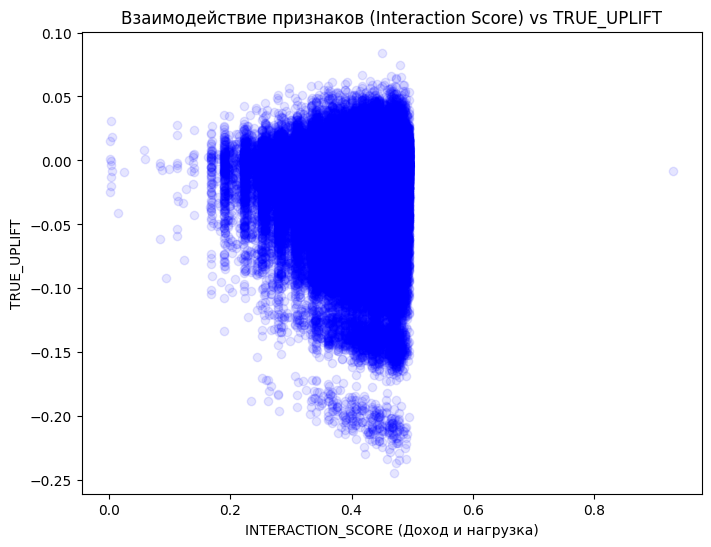

In [30]:
# Связь Interaction Score и True Uplift
plt.figure(figsize=(8, 6))
plt.scatter(df['INTERACTION_SCORE'], df['TRUE_UPLIFT'], alpha=0.1, color='blue')
plt.title("Взаимодействие признаков (Interaction Score) vs TRUE_UPLIFT")
plt.xlabel("INTERACTION_SCORE (Доход и нагрузка)")
plt.ylabel("TRUE_UPLIFT")
plt.show()

# Что смотрим: Наличие корреляции.
# Что ожидаем увидеть: Чем выше INTERACTION_SCORE, тем сильнее должен быть выражен
# эффект (отрицательный аплифт), что создает "контекстуальную" сложность для моделей.